# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

k_G = 6.67 * 10**-11
k_g = 9.81
k_me = 5.9 * 10**24
k_mm = 7.3 * 10**22
k_ma = 5500
k_re = 6378 * 10**3
k_rm = 1737 * 10**3
k_d = 3.8 * 10**8
k_sev = 2.4 * 10**3
k_sbr = 1.3 * 10**4
k_swm = 2.8 * 10**6
k_sdm = 7.5 * 10**5

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def Potential(mass: float, x0: float, y0: float, x1: float, y1: float) -> float: # included type hints, which i personally dislike
    
    # doc
    """
    This function returns the gravitational potential at a point (x, y)
    given the location (x_0, y_0) of one mass.
    
    This function approximates the body as a point mass and should not be
    used to calculate potential inside of a mass distribution.

    This function operates in 2-D space. I really don't know why anything
    intended for use with space science wouldn't operate in 3-space, but
    oh well, we'll just keep z = 0.

    Arguments
    mass: mass of the body; any input castable to float
    x0: x position of the mass; any input castable to float
    y0: y position of the mass; any input castable to float
    x1: x position to calculate potential; any input castable to float
    y1: y position to calculate potential; any input castable to float
    
    Outputs
    potential: gravitational potential; type float
    """

    # casting all the variables to float manually as pre-condition check
    try:
        mass = float(mass)
        x0 = float(x0)
        y0 = float(y0)
        x1 = float(x1)
        y1 = float(y1)
    except:
        raise TypeError("wrong type bozo")
    
    r = math.sqrt((x1 - x0)**2 + (y1 - y0)**2)
    if r == 0:
        return 0
    potential = -1 * mass * k_G / r
        
    # post-conditions
    assert potential < 0, isinstance(potential, float)
    
    return potential

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

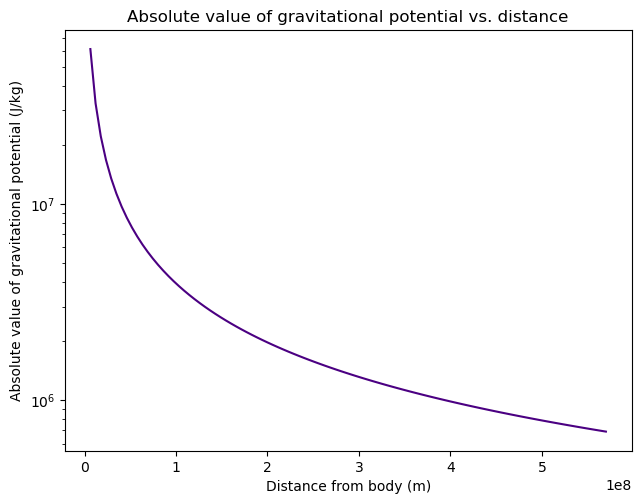

In [4]:
friendlyPotential = np.vectorize(Potential)
fig, ax = plt.subplots()
fig.tight_layout()

x = np.linspace(k_re, 1.5 * k_d, 100) # avoid potential(0) = 0
y = -1 * friendlyPotential(k_me, 0, 0, x, 0) # log scale not allowed for values < 0

ax.set_yscale("log")
ax.set_title("Absolute value of gravitational potential vs. distance")
ax.set_xlabel("Distance from body (m)")
ax.set_ylabel("Absolute value of gravitational potential (J/kg)")
ax.plot(x, y, c='indigo')

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

(501, 501) (501, 501)


Text(71.42222222222227, 0.5, 'distance in some orthogonal direction\nset the plane however you like')

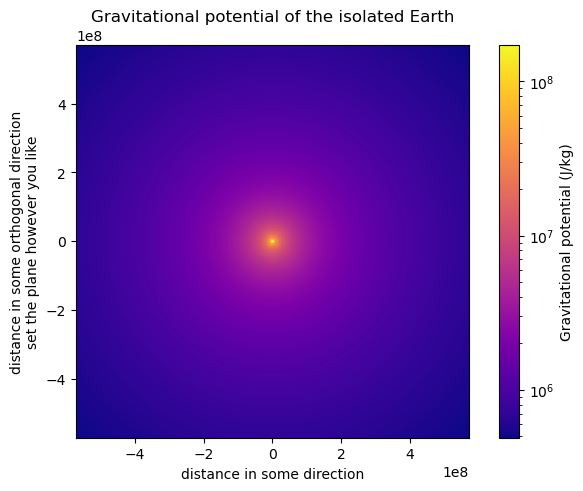

In [5]:
xarray = np.linspace(1.5 * -k_d, 1.5 * k_d, 501)
yarray = np.linspace(1.5 * -k_d, 1.5 * k_d, 501)

xgrid, ygrid = np.meshgrid(xarray, yarray)
print(xgrid.shape, ygrid.shape)

phi = friendlyPotential(k_me, 0, 0, xgrid, ygrid)

fig, ax = plt.subplots()
ax.set_aspect("equal")

# i found how to set log-scale colors
from matplotlib.colors import LogNorm # then use this in the mesh assignment

meshuggah = ax.pcolormesh(xgrid, ygrid, np.abs(phi), cmap='plasma', norm=LogNorm())

cbar = fig.colorbar(meshuggah)
cbar.set_label("Gravitational potential (J/kg)")
plt.tight_layout()

ax.set_aspect("equal") # square

ax.set_title("Gravitational potential of the isolated Earth")
ax.set_xlabel("distance in some direction")
ax.set_ylabel("distance in some orthogonal direction\nset the plane however you like")

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

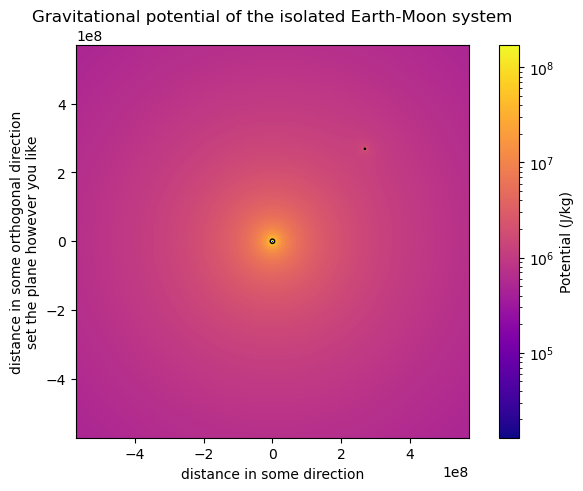

In [6]:
# field, force, potential, potential energy all obey superposition
# so we should just be able to add the moon potential

phi_moon = friendlyPotential(k_mm, k_d / math.sqrt(2), k_d / math.sqrt(2), xgrid, ygrid)

fig, ax = plt.subplots()
ax.set_aspect("equal")

# i found how to set log-scale colors
from matplotlib.colors import LogNorm # then use this in the mesh assignment

meshuggah = ax.pcolormesh(xgrid, ygrid, np.abs(phi + phi_moon), cmap='plasma', norm=LogNorm())

cbar = fig.colorbar(meshuggah)
cbar.set_label("Potential (J/kg)")
plt.tight_layout()

ax.set_aspect("equal") # square

ax.set_title("Gravitational potential of the isolated Earth-Moon system")
ax.set_xlabel("distance in some direction")
ax.set_ylabel("distance in some orthogonal direction\nset the plane however you like")

# i have added circles to show earth and moon
# because anything inside is invalid
from matplotlib.patches import Circle
ax.add_patch(Circle((0, 0), k_re, fill=False))
ax.add_patch(Circle((k_d / math.sqrt(2), k_d / math.sqrt(2)), 1738000, fill=False))

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

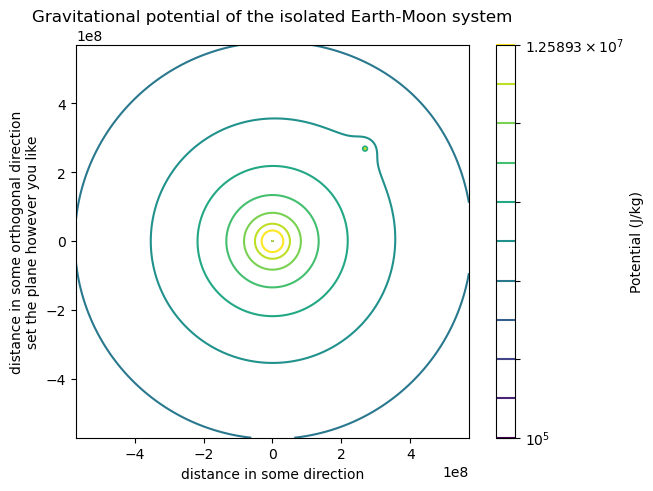

In [7]:
# we'll reuse the code from above just replacing meshgrid with contour

fig, ax = plt.subplots()
ax.set_aspect("equal")

# i found how to set log-scale colors
from matplotlib.colors import LogNorm # then use this in the mesh assignment

contour = ax.contour(xgrid, ygrid, np.abs(phi + phi_moon), norm=LogNorm(), cmap='viridis', levels=np.logspace(5, 7.1, 11))

cbar = fig.colorbar(contour)
cbar.set_label("Potential (J/kg)")
plt.tight_layout()

ax.set_aspect("equal") # square

ax.set_title("Gravitational potential of the isolated Earth-Moon system");
ax.set_xlabel("distance in some direction");
ax.set_ylabel("distance in some orthogonal direction\nset the plane however you like");

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def Force(mass1: float, mass2: float, x1: float, y1: float, x2: float, y2: float) -> float: # included type hints, which i personally dislike
    
    # doc
    """
    This function returns the force that one mass exerts on another as
    two Cartesian vector components.
    
    This function approximates the bodies as point masses.

    This function operates in 2-D space. I really don't know why anything
    intended for use with space science wouldn't operate in 3-space, but
    oh well, we'll just keep z = 0.

    Arguments
    mass1: mass of the body; any input castable to float
    x1: x position of the first mass; any input castable to float
    y1: y position of the first mass; any input castable to float
    x2: x position of the second mass; any input castable to float
    y2: y position of the second mass; any input castable to float
    
    Outputs
    F_x: x-component of the gravitational force of the first mass on the
    the second; type float
    F_y: y-component of the gravitational force of the first mass on the
    the second; type float
    """

    # casting all the variables to float manually as pre-condition check
    try:
        mass1 = float(mass1)
        mass2 = float(mass2)
        x1 = float(x1)
        y1 = float(y1)
        x2 = float(x2)
        y2 = float(y2)
    except:
        raise TypeError("wrong type bozo")
    
    r = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    if r == 0:
        return 0, 0

    theta = np.arctan2(y2 - y1, x2 - x1)

    F = mass1 * mass2 * k_G / r**2
    F_x = np.cos(theta) * F
    F_y = np.sin(theta) * F
        
    # post-conditions
    assert isinstance(F_x, float)
    assert isinstance(F_y, float)
    
    return F_x, F_y

Force(1500000, 1700000, 0, 0, 3, 4)

# define a vectorizable version here instead of later
friendlyForce = np.vectorize(Force)

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

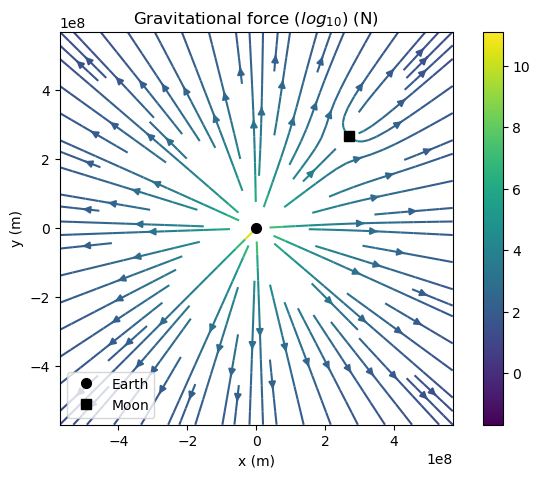

In [9]:
xarray = np.linspace(1.5 * -k_d, 1.5 * k_d, 201)
yarray = np.linspace(1.5 * -k_d, 1.5 * k_d, 201)

xgrid, ygrid = np.meshgrid(xarray, yarray)

f_e_x, f_e_y = friendlyForce(k_me, k_ma, 0, 0, xgrid, ygrid)
m_coord = k_d / np.sqrt(2)
f_m_x, f_m_y = friendlyForce(k_mm, k_ma, m_coord, m_coord, xgrid, ygrid)

fig, ax = plt.subplots()
ax.set_aspect("equal") # square

log_magnitude = np.log(np.sqrt((f_e_x + f_m_x)**2 + (f_e_y + f_m_y)**2))
streamplot = ax.streamplot(xarray, yarray, (f_e_x + f_m_x), (f_e_y + f_m_y), color=log_magnitude, cmap='viridis')

cbar = fig.colorbar(streamplot.lines)
plt.tight_layout()

#from matplotlib.patches import Rectangle
#ax.add_patch(Circle((0, 0), k_re * 3, color='black', label="Earth")) # need label for legend
#10**7.5 is just an arbitrary square size that looked good enough
#ax.add_patch(Rectangle((k_d / math.sqrt(2) - 10**7.5/2, k_d / math.sqrt(2)-10**7.5/2), 10**7.5, 10**7.5, color='black', label="Moon"))

# above messed up the legend. Luckily there is a WAY simpler method
ax.plot(0, 0, 'o', markersize=7, color='black', label="Earth")
ax.plot(k_d / math.sqrt(2), k_d / math.sqrt(2), 's', markersize=7, color="black", label="Moon")
ax.set_title("Gravitational force ($log_{10}$) (N)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.legend(loc="lower left");

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

$$
|F_{\text{moon}}| = |F_{\text{earth}}|
$$

$$
G \frac{m_{\text{moon}} m_{\text{rocket}}}{r_{\text{moon}}^{2}}
=
G \frac{m_{\text{earth}} m_{\text{rocket}}}{r_{\text{earth}}^{2}}
$$

$$
\frac{r_{\text{moon}}^{2}}{r_{\text{earth}}^{2}}
=
\frac{m_{\text{moon}}}{m_{\text{earth}}}
$$

$$
\frac{d_{\text{earth,moon}} - r_{\text{earth}}}{r_{\text{moon}}}
=
\sqrt{\frac{m_{\text{moon}}}{m_{\text{earth}}}}
$$

$$
\frac{d_{\text{earth,moon}}}{r_{\text{earth}}}
=
\sqrt{\frac{m_{\text{moon}}}{m_{\text{earth}}}} + 1
$$

$$
r_{\text{earth}}
=
\frac{d_{\text{earth,moon}}}{\sqrt{\frac{m_{\text{moon}}}{m_{\text{earth}}}} + 1}
$$

# whew

And your updated plot, including the balance point, goes in the cell below.

what proportion of th eway there? 0.8999009129258294
mass ratio 80.82191780821918


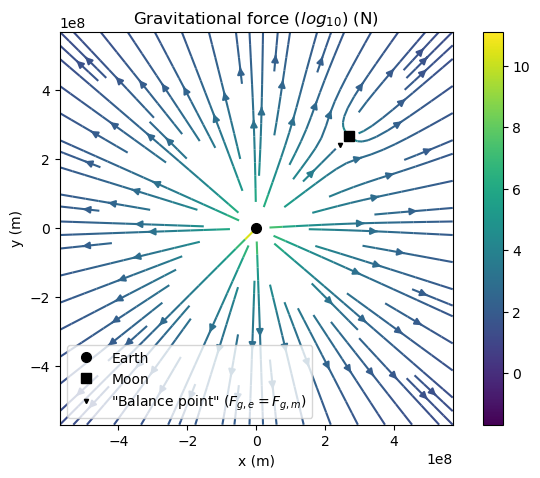

In [15]:
xarray = np.linspace(1.5 * -k_d, 1.5 * k_d, 201)
yarray = np.linspace(1.5 * -k_d, 1.5 * k_d, 201)

xgrid, ygrid = np.meshgrid(xarray, yarray)

f_e_x, f_e_y = friendlyForce(k_me, k_ma, 0, 0, xgrid, ygrid)
m_coord = k_d / np.sqrt(2)
f_m_x, f_m_y = friendlyForce(k_mm, k_ma, m_coord, m_coord, xgrid, ygrid)

fig, ax = plt.subplots()
ax.set_aspect("equal") # square

log_magnitude = np.log(np.sqrt((f_e_x + f_m_x)**2 + (f_e_y + f_m_y)**2))
streamplot = ax.streamplot(xarray, yarray, (f_e_x + f_m_x), (f_e_y + f_m_y), color=log_magnitude, cmap='viridis')

cbar = fig.colorbar(streamplot.lines)
plt.tight_layout()

#from matplotlib.patches import Rectangle
#ax.add_patch(Circle((0, 0), k_re * 3, color='black', label="Earth")) # need label for legend
#10**7.5 is just an arbitrary square size that looked good enough
#ax.add_patch(Rectangle((k_d / math.sqrt(2) - 10**7.5/2, k_d / math.sqrt(2)-10**7.5/2), 10**7.5, 10**7.5, color='black', label="Moon"))

# above messed up the legend. Luckily there is a WAY simpler method
ax.plot(0, 0, 'o', markersize=7, color='black', label="Earth")
ax.plot(k_d / math.sqrt(2), k_d / math.sqrt(2), 's', markersize=7, color="black", label="Moon")
ax.set_title("Gravitational force ($log_{10}$) (N)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

# ADD THE BALANCE POINT VVV
r_from_earth = k_d / (np.sqrt(k_mm/k_me) + 1)
coordinate = r_from_earth / math.sqrt(2)
ax.plot(coordinate, coordinate, 'v', markersize=3, color='black', label='"Balance point" ($F_{g,e}=F_{g,m}$)')

ax.legend(loc='lower left');

print("what proportion of th eway there?", r_from_earth / k_d)
print("mass ratio", k_me/k_mm)

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

$\textrm{ANSWER:}$ The balance point is close to the Moon (~90% or the distance from the earth to the moon). Yes, this makes sense. The Moon is much less massive than Earth, so a third body would have to be much closer to the Moon to experience the same force as it would from Earth.

Quantitatively, the Earth is about 81 times more massive than the moon, so a radius 9 times larger and thus a force scaled by 1/9^2 = 1/81 would cancel exactly. I think if you ignore the Sun you can characterize this as a Lagrange point.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [18]:
# expression for T above
T = (k_swm - k_sdm) / k_sbr
print(T)

157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [34]:
# contrary to my initial understanding we are NOT measuring the total
# change in velocity from the launchpad. this is instantaneous delta V

def DeltaV(time: float, wet_mass: float, dry_mass: float, burn_rate: float, exhaust_speed: float, g: float) -> float:
    
    # doc
    """
    This function returns the change in velocity (dv/dt) for a rocket
    following the Tsiolkovsky rocket equation.

    The rocket burns fuel at a constant rate until it reaches its
    dry mass, at which point delta V reaches zero.

    Arguments
    time: time since launch; any input castable to float
    wet_mass: combined fuel + rocket mass; any input castable to float
    dry_mass: mass of rocket w/o fuel; any input castable to float
    burn_rate: rate at which fuel is expelled; any input castable to float
    exhaust_speed: velocity at which fuel is expelled; any input castable to float
    g: relevant gravitational acceleration constant; any input castable to float

    Outputs
    delta_v: rate of change of velocity at time t; type float
    """

    # casting variables as floats (pre-condition check)
    try:
        time = float(time)
        wet_mass = float(wet_mass)
        dry_mass = float(dry_mass)
        burn_rate = float(burn_rate)
        exhaust_speed = float(exhaust_speed)
        g = float(g)
    except:
        raise TypeError("wrong type bozo")

    # compute burn time
    burn_time = (wet_mass - dry_mass) / burn_rate
    if time > burn_time:
        return 0.0

    mass_at_t = wet_mass - burn_rate * time

    if mass_at_t <= 0:
        # at this point some unphysical arguments have been passed
        # i actually don't know if burn time return would let us get here
        # but might as well
        return 0.0

    delta_v = exhaust_speed * math.log(wet_mass / mass_at_t) - g * time

    # post-conditions
    assert isinstance(delta_v, float)

    return delta_v

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [35]:
from scipy.integrate import quad

# quad integrates over the first variable in the function
h, err = quad(DeltaV, 0, T, args=(k_swm, k_sdm, k_sbr, k_sev, k_g))

print(h)

74093.98013366401


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

$\textrm{ANSWER:}$ Calculations for T and h predict a burn time of 157.7 seconds and an altitude of 74.09km. This is a shorter burn time and higher altitude than observed, though not dramatically so. If we assume the engineers' provided constants used to calculate this value are perfectly precise, there are still a couple of factors unaccounted for.

The biggest factor is probably the fact that not all of the thrust actually goes into propulsion; some is spent counteracting the gravitational force.

Air resistance (scales linearly with fluid density and and area and quadratically with velocity) will also lead to lower altitude.

There are also a few engineering questions which, while tractable, may never be perfectly optimized. 1) Unburnt fuel may be a limiting factor. 2) In addition to air resistance, some momentum carried by the expelled fuel is in the radial direction and thus the "effective" fuel velocity (i.e. in the longitudinal direction) is lower than the actual velocity. This results in a lower maximum altitude. 3) Burn time is also expected to be longer as the constant specified burn rate is really a maximum burn rate. The rate of fuel expulsion is continuous and must start from zero.